In [1]:
print("Distribution of Order Value and Delivery Time")

Distribution of Order Value and Delivery Time


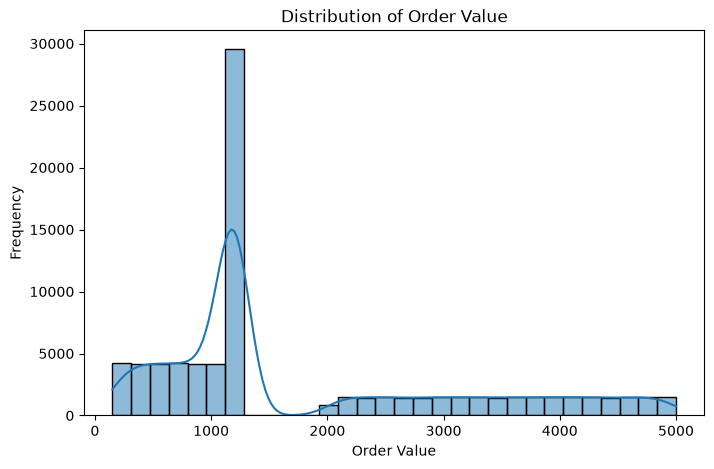

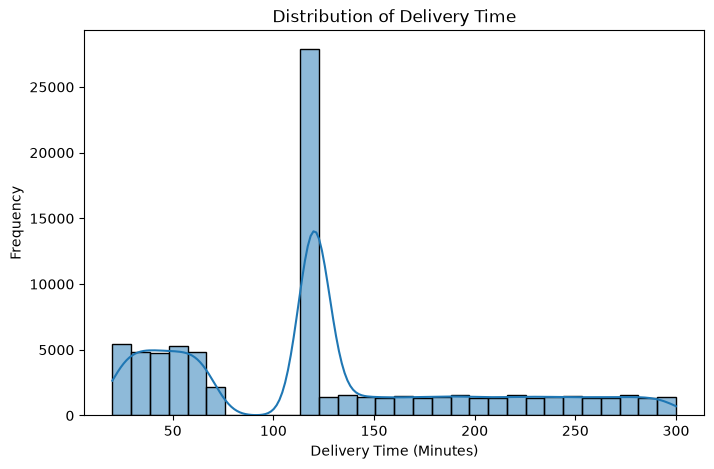

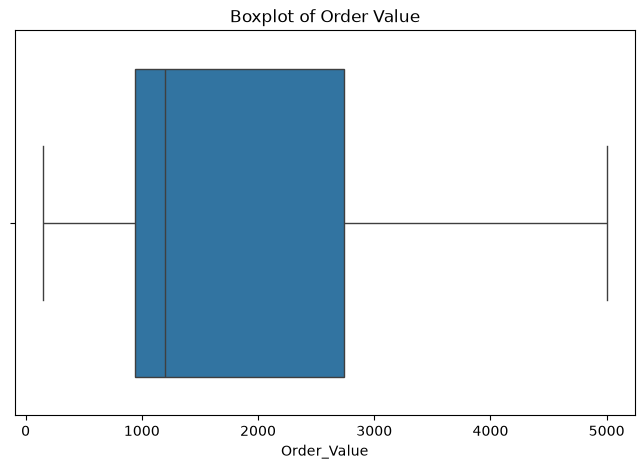

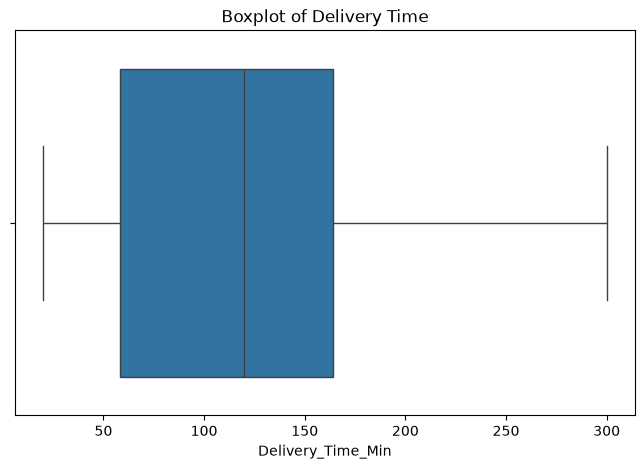

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv(r"C:\Users\srinithi\Documents\ONLINE_FOOD_DELIVERY_FINAL_CLEANED.csv")

# Histogram for Order Value
plt.figure(figsize=(8,5))
sns.histplot(df['Order_Value'], bins=30, kde=True)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

# Histogram for Delivery Time
plt.figure(figsize=(8,5))
sns.histplot(df['Delivery_Time_Min'], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Frequency")
plt.show()

# Boxplot for Order Value
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Order_Value'])
plt.title("Boxplot of Order Value")
plt.show()

# Boxplot for Delivery Time
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Delivery_Time_Min'])
plt.title("Boxplot of Delivery Time")
plt.show()

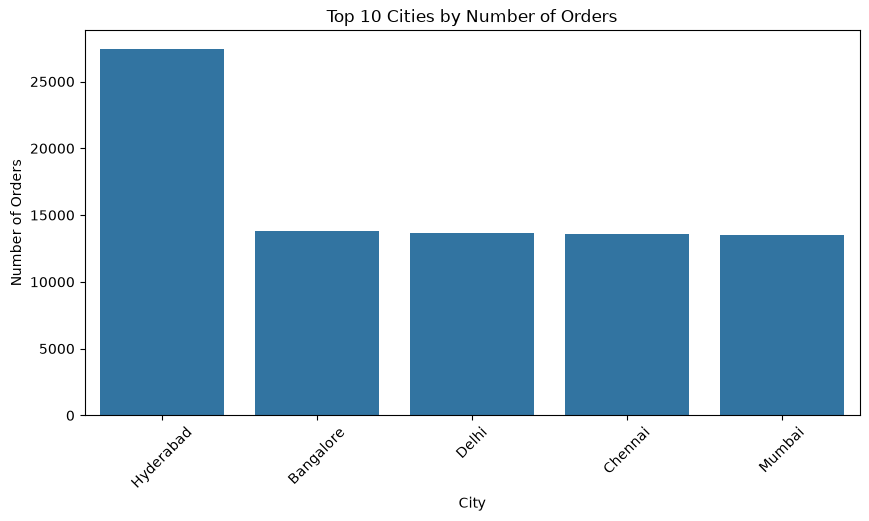

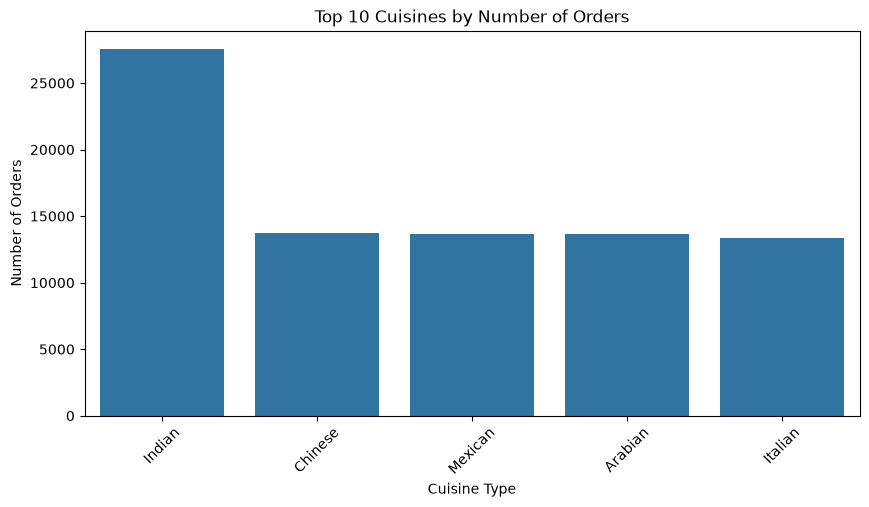

In [9]:
top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cities.index, y=top_cities.values)
plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()


top_cuisines = df['Cuisine_Type'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cuisines.index, y=top_cuisines.values)
plt.title("Top 10 Cuisines by Number of Orders")
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Day_Type
Weekday    58714
Weekend    23267
Name: count, dtype: int64


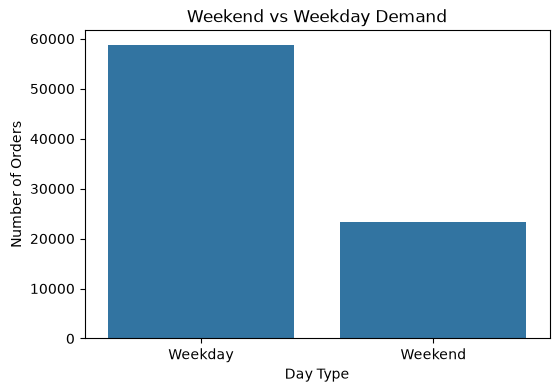

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Create day type column
df['Day_Type'] = df['Order_Date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

# Count orders
print(df['Day_Type'].value_counts())

# Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Day_Type', order=['Weekday', 'Weekend'])
plt.title("Weekend vs Weekday Demand")
plt.xlabel("Day Type")
plt.ylabel("Number of Orders")
plt.show()

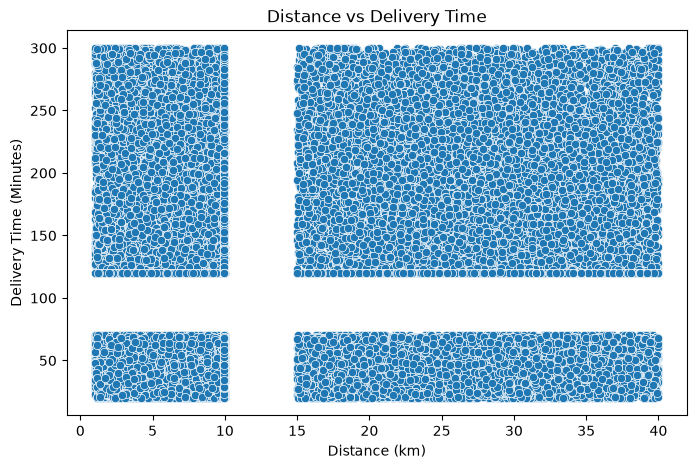

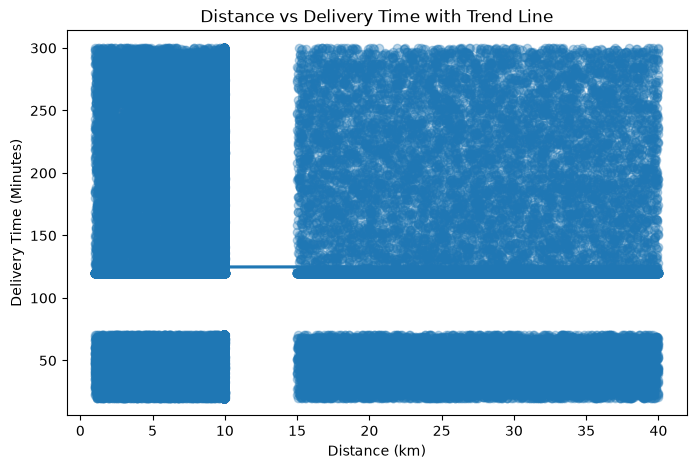

Correlation between Distance and Delivery Time: 0.0009152954746447551


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Distance_km', y='Delivery_Time_Min')
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Minutes)")
plt.show()

# Regression plot
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='Distance_km', y='Delivery_Time_Min', scatter_kws={'alpha':0.3})
plt.title("Distance vs Delivery Time with Trend Line")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Minutes)")
plt.show()

# Correlation
corr = df['Distance_km'].corr(df['Delivery_Time_Min'])
print("Correlation between Distance and Delivery Time:", corr)

Cancellation_Reason
Not Cancelled         74536
Late Delivery          2544
Customer Cancelled     2479
Restaurant Issue       2422
Name: count, dtype: int64


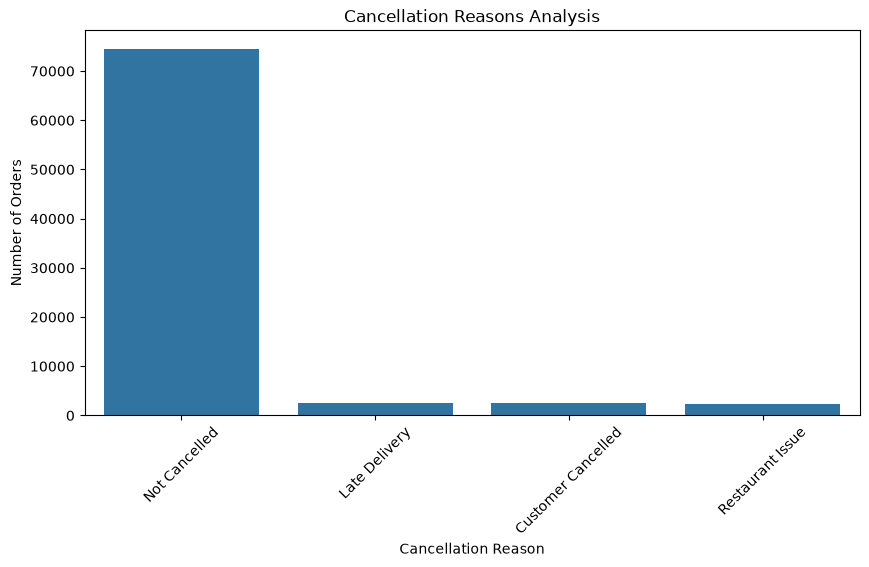

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count cancellation reasons
cancel_counts = df['Cancellation_Reason'].value_counts()
print(cancel_counts)

# Bar chart
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Cancellation_Reason',
              order=df['Cancellation_Reason'].value_counts().index)
plt.title("Cancellation Reasons Analysis")
plt.xlabel("Cancellation Reason")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Cancellation_Reason
Not Cancelled         4936
Late Delivery         2544
Customer Cancelled    2479
Restaurant Issue      2422
Name: count, dtype: int64


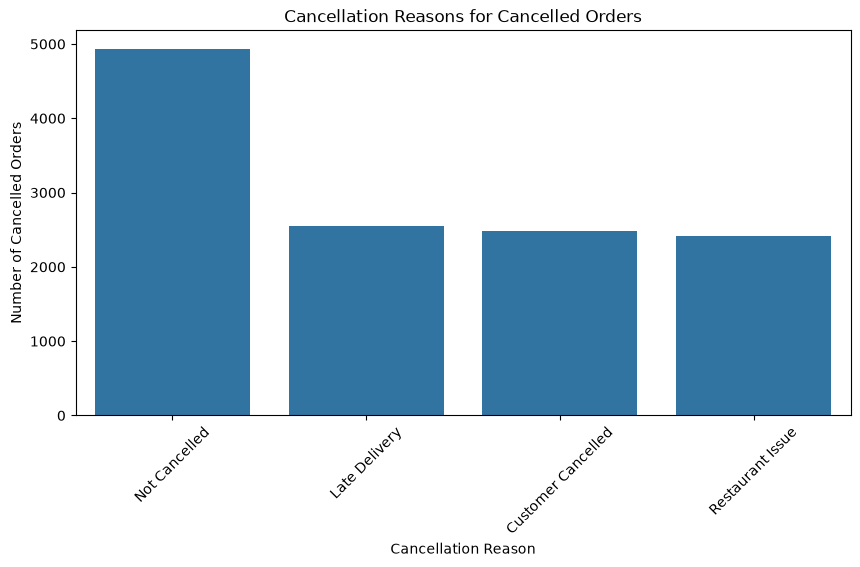

In [13]:
cancelled_df = df[df['Order_Status'] == 'Cancelled']

cancel_counts = cancelled_df['Cancellation_Reason'].value_counts()
print(cancel_counts)

plt.figure(figsize=(10,5))
sns.countplot(data=cancelled_df, x='Cancellation_Reason',
              order=cancelled_df['Cancellation_Reason'].value_counts().index)
plt.title("Cancellation Reasons for Cancelled Orders")
plt.xlabel("Cancellation Reason")
plt.ylabel("Number of Cancelled Orders")
plt.xticks(rotation=45)
plt.show()

                   Customer_Age  Delivery_Time_Min  Distance_km  Order_Value  \
Customer_Age           1.000000          -0.012640    -0.004013    -0.002825   
Delivery_Time_Min     -0.012640           1.000000     0.000915     0.004052   
Distance_km           -0.004013           0.000915     1.000000     0.002347   
Order_Value           -0.002825           0.004052     0.002347     1.000000   
Discount_Applied       0.002571          -0.001107     0.003391    -0.000309   
Final_Amount          -0.001275           0.002279     0.001932     0.790797   
Delivery_Rating       -0.003590          -0.000779    -0.000591     0.001923   
Restaurant_Rating      0.000051           0.000899     0.004309    -0.003120   
Profit_Margin          0.001196          -0.001848     0.003420    -0.003671   

                   Discount_Applied  Final_Amount  Delivery_Rating  \
Customer_Age               0.002571     -0.001275        -0.003590   
Delivery_Time_Min         -0.001107      0.002279        -0

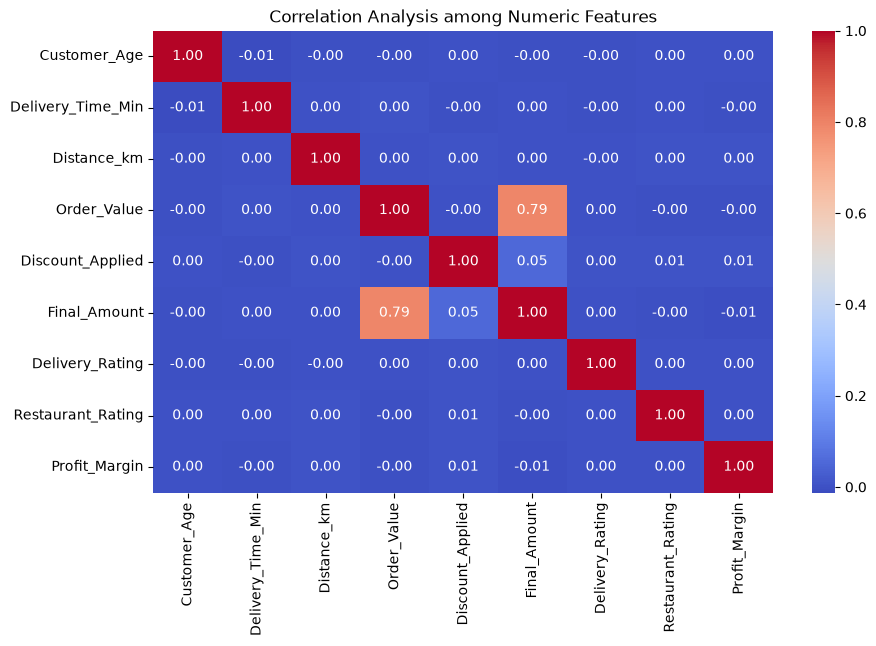

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = num_df.corr()
print(corr_matrix)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Analysis among Numeric Features")
plt.show()